In [7]:
import torch
import torch.nn as nn
import pandas as pd
import numpy as np
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from experiment_utils import run_one_experiment, save_result_v1, run, MLPClassifier

In [3]:
FEATURE_COLS = [
    "home_rank",
    "away_rank",
    "home_elo",
    "away_elo",
    "home_form_sma5",
    "away_form_sma5",
    "home_form_ema33",
    "away_form_ema33"
]

data = pd.read_csv("../data/Processed_Project_Data/fifa_and_elo_with_ema.csv")

data = data.drop(columns=["Unnamed: 0"], errors="ignore")

data["date"] = pd.to_datetime(data["date"], format="mixed")
data = data.sort_values("date").reset_index(drop=True)

data = data.dropna(subset=FEATURE_COLS + ["result"]).reset_index(drop=True)

X = data[FEATURE_COLS].values.astype(np.float32)

y = (data["result"].values + 1).astype(np.int64)

X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.2,
    shuffle=False
)

scaler = StandardScaler()

X_train_s = scaler.fit_transform(X_train)
X_test_s = scaler.transform(X_test)

X_train_tensor = torch.tensor(X_train_s, dtype=torch.float32)
y_train_tensor = torch.tensor(y_train, dtype=torch.long)

X_test_tensor = torch.tensor(X_test_s, dtype=torch.float32)
y_test_tensor = torch.tensor(y_test, dtype=torch.long)

print("Train size:", len(X_train_tensor), "Test size:", len(X_test_tensor))

Train size: 888 Test size: 222


In [4]:
import random
import numpy as np

seed = 42

random.seed(seed)
np.random.seed(seed)
torch.manual_seed(seed)

input_dim = X_train_tensor.shape[1]

model = MLPClassifier(input_dim=input_dim)

criterion = nn.CrossEntropyLoss()

optimizer = torch.optim.Adam(
    model.parameters(),
    lr=0.001
)

Epoch 50/1000 | train loss = 0.8589 | val loss = 0.7342 | val acc = 0.6854
Epoch 100/1000 | train loss = 0.8518 | val loss = 0.7375 | val acc = 0.6798
Epoch 150/1000 | train loss = 0.8399 | val loss = 0.7311 | val acc = 0.6629
Epoch 200/1000 | train loss = 0.7989 | val loss = 0.7296 | val acc = 0.6742
Epoch 250/1000 | train loss = 0.8039 | val loss = 0.7307 | val acc = 0.6404
Epoch 300/1000 | train loss = 0.8021 | val loss = 0.7401 | val acc = 0.6348
Epoch 350/1000 | train loss = 0.7853 | val loss = 0.7454 | val acc = 0.6292
Epoch 400/1000 | train loss = 0.7431 | val loss = 0.7604 | val acc = 0.6011
Epoch 450/1000 | train loss = 0.7782 | val loss = 0.7594 | val acc = 0.6461
Epoch 500/1000 | train loss = 0.7500 | val loss = 0.7661 | val acc = 0.6292
Epoch 550/1000 | train loss = 0.7393 | val loss = 0.7736 | val acc = 0.6292
Epoch 600/1000 | train loss = 0.7421 | val loss = 0.7675 | val acc = 0.6236
Epoch 650/1000 | train loss = 0.7443 | val loss = 0.7773 | val acc = 0.6180
Epoch 700/100

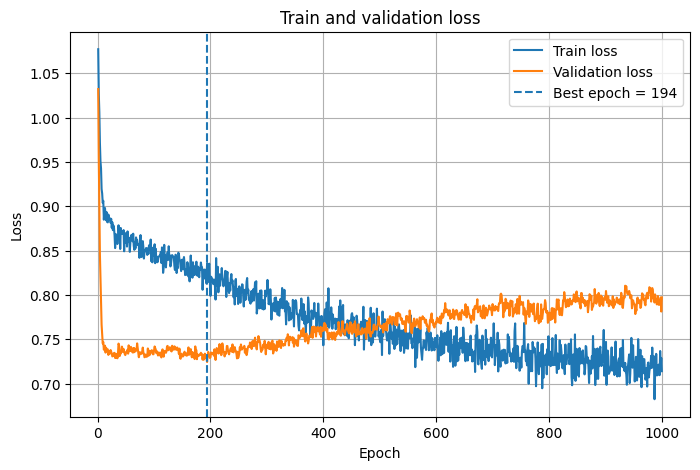

0.6621621621621622

In [5]:
run_one_experiment(model, criterion, optimizer, X_train_tensor, y_train_tensor, X_test_tensor, y_test_tensor)

In [6]:
best_num_epochs = 122

summary, results_df = run(
    model_class=MLPClassifier,
    X_train_tensor=X_train_tensor,
    y_train_tensor=y_train_tensor,
    X_test_tensor=X_test_tensor,
    y_test_tensor=y_test_tensor,
    num_epochs=best_num_epochs,
)

Run 1/10
Accuracy: 0.6667 | Precision: 0.6101 | Recall: 0.5757 | Specificity: 0.8118 | F1: 0.5519

Run 2/10
Accuracy: 0.6622 | Precision: 0.5721 | Recall: 0.5627 | Specificity: 0.8082 | F1: 0.5130

Run 3/10
Accuracy: 0.6667 | Precision: 0.6088 | Recall: 0.5656 | Specificity: 0.8077 | F1: 0.5256

Run 4/10
Accuracy: 0.6757 | Precision: 0.6549 | Recall: 0.5798 | Specificity: 0.8128 | F1: 0.5512

Run 5/10
Accuracy: 0.6757 | Precision: 0.6425 | Recall: 0.5898 | Specificity: 0.8135 | F1: 0.5765

Run 6/10
Accuracy: 0.6622 | Precision: 0.6587 | Recall: 0.5645 | Specificity: 0.8037 | F1: 0.5314

Run 7/10
Accuracy: 0.6622 | Precision: 0.6584 | Recall: 0.5585 | Specificity: 0.8034 | F1: 0.5109

Run 8/10
Accuracy: 0.6441 | Precision: 0.5470 | Recall: 0.5503 | Specificity: 0.7982 | F1: 0.5202

Run 9/10
Accuracy: 0.6667 | Precision: 0.6222 | Recall: 0.5818 | Specificity: 0.8126 | F1: 0.5610

Run 10/10
Accuracy: 0.6712 | Precision: 0.6453 | Recall: 0.5787 | Specificity: 0.8101 | F1: 0.5566

Summary o

In [ ]:
save_result_v1(
    experiment_name="Experiment_3-3_ranks_SMA_best_EMA_best",
    summary=summary
)


Saved result for Experiment_3-3_ranks_SMA_best
File: ../results/experiment_summary_v1.csv
